Success: TIFS_NGI_IP.png


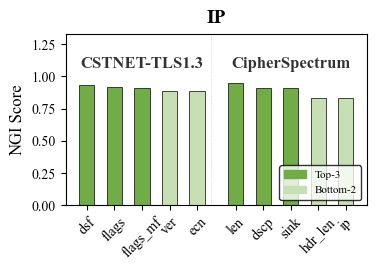

Success: TIFS_NGI_TCP_Core.png


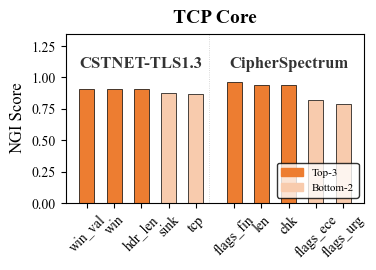

Success: TIFS_NGI_TCP_Options.png


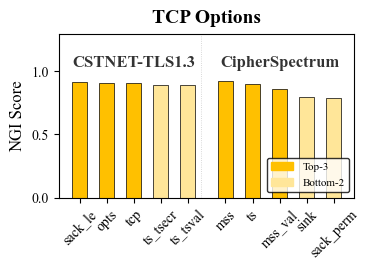

Success: TIFS_NGI_TLS_Handshake.png


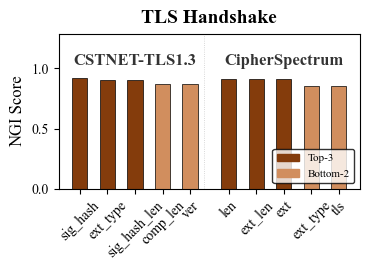

Success: TIFS_NGI_TLS_Record.png


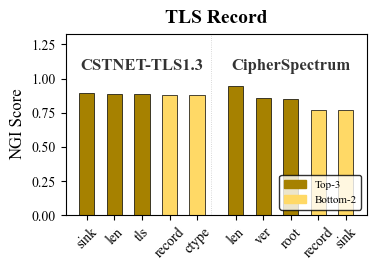

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

# 1. 风格设置：IEEE TIFS 严谨学术风
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False

# 2. 完整数据准备
data_list = [
    # --- CSTNET-TLS1.3 ---
    ("IP", "CSTNET-TLS1.3", "dsf", 0.9293, "Top"),
    ("IP", "CSTNET-TLS1.3", "flags", 0.9143, "Top"),
    ("IP", "CSTNET-TLS1.3", "flags_mf", 0.9119, "Top"),
    ("IP", "CSTNET-TLS1.3", "ver", 0.8835, "Btm"),
    ("IP", "CSTNET-TLS1.3", "ecn", 0.8835, "Btm"),

    ("TCP Core", "CSTNET-TLS1.3", "win_val", 0.9108, "Top"),
    ("TCP Core", "CSTNET-TLS1.3", "win", 0.9094, "Top"),
    ("TCP Core", "CSTNET-TLS1.3", "hdr_len", 0.9063, "Top"),
    ("TCP Core", "CSTNET-TLS1.3", "sink", 0.8801, "Btm"),
    ("TCP Core", "CSTNET-TLS1.3", "tcp", 0.8705, "Btm"),

    ("TCP Options", "CSTNET-TLS1.3", "sack_le", 0.9106, "Top"),
    ("TCP Options", "CSTNET-TLS1.3", "opts", 0.9074, "Top"),
    ("TCP Options", "CSTNET-TLS1.3", "tcp", 0.9056, "Top"),
    ("TCP Options", "CSTNET-TLS1.3", "ts_tsecr", 0.8931, "Btm"),
    ("TCP Options", "CSTNET-TLS1.3", "ts_tsval", 0.8924, "Btm"),

    ("TLS Handshake", "CSTNET-TLS1.3", "sig_hash", 0.9167, "Top"),
    ("TLS Handshake", "CSTNET-TLS1.3", "ext_type", 0.9064, "Top"),
    ("TLS Handshake", "CSTNET-TLS1.3", "sig_hash_len", 0.9042, "Top"),
    ("TLS Handshake", "CSTNET-TLS1.3", "comp_len", 0.8730, "Btm"),
    ("TLS Handshake", "CSTNET-TLS1.3", "ver", 0.8727, "Btm"),

    ("TLS Record", "CSTNET-TLS1.3", "sink", 0.8913, "Top"),
    ("TLS Record", "CSTNET-TLS1.3", "len", 0.8904, "Top"),
    ("TLS Record", "CSTNET-TLS1.3", "tls", 0.8893, "Top"),
    ("TLS Record", "CSTNET-TLS1.3", "record", 0.8829, "Btm"),
    ("TLS Record", "CSTNET-TLS1.3", "ctype", 0.8829, "Btm"),

    # --- CipherSpectrum ---
    ("IP", "CipherSpectrum", "len", 0.9480, "Top"),
    ("IP", "CipherSpectrum", "dscp", 0.9087, "Top"),
    ("IP", "CipherSpectrum", "sink", 0.9064, "Top"),
    ("IP", "CipherSpectrum", "hdr_len", 0.8335, "Btm"),
    ("IP", "CipherSpectrum", "ip", 0.8329, "Btm"),

    ("TCP Core", "CipherSpectrum", "flags_fin", 0.9607, "Top"),
    ("TCP Core", "CipherSpectrum", "len", 0.9385, "Top"),
    ("TCP Core", "CipherSpectrum", "chk", 0.9381, "Top"),
    ("TCP Core", "CipherSpectrum", "flags_ece", 0.8194, "Btm"),
    ("TCP Core", "CipherSpectrum", "flags_urg", 0.7919, "Btm"),

    ("TCP Options", "CipherSpectrum", "mss", 0.9226, "Top"),
    ("TCP Options", "CipherSpectrum", "ts", 0.8982, "Top"),
    ("TCP Options", "CipherSpectrum", "mss_val", 0.8563, "Top"),
    ("TCP Options", "CipherSpectrum", "sink", 0.7918, "Btm"),
    ("TCP Options", "CipherSpectrum", "sack_perm", 0.7908, "Btm"),

    ("TLS Handshake", "CipherSpectrum", "len", 0.9153, "Top"),
    ("TLS Handshake", "CipherSpectrum", "ext_len", 0.9120, "Top"),
    ("TLS Handshake", "CipherSpectrum", "ext", 0.9074, "Top"),
    ("TLS Handshake", "CipherSpectrum", "ext_type", 0.8517, "Btm"),
    ("TLS Handshake", "CipherSpectrum", "tls", 0.8510, "Btm"),

    ("TLS Record", "CipherSpectrum", "len", 0.9464, "Top"),
    ("TLS Record", "CipherSpectrum", "ver", 0.8584, "Top"),
    ("TLS Record", "CipherSpectrum", "root", 0.8536, "Top"),
    ("TLS Record", "CipherSpectrum", "record", 0.7674, "Btm"),
    ("TLS Record", "CipherSpectrum", "sink", 0.7662, "Btm"),
]

df = pd.DataFrame(data_list, columns=["Layer", "Dataset", "Field", "NGI", "Category"])
datasets_order = ["CSTNET-TLS1.3", "CipherSpectrum"]

# 定义符合图片示意图的协议层配色方案
#  ETH: #87AADE, IP: #A8D08D, TCP: #FFD966, TLS: #bf9000
color_map = {
    "ETH": {"Top": "#5B84C4", "Btm": "#B4C7E7"},      # 蓝色系
    "IP": {"Top": "#70AD47", "Btm": "#C6E0B4"},       # 绿色系
    "TCP Core": {"Top": "#ED7D31", "Btm": "#F8CBAD"}, # 橙黄系
    "TCP Options": {"Top": "#FFC000", "Btm": "#FFE699"}, # 纯黄系
    "TLS Handshake": {"Top": "#843C0C", "Btm": "#D18E5E"}, # 棕色系
    "TLS Record": {"Top": "#A68100", "Btm": "#FFD966"},    # 金棕系
    "TLS x509": {"Top": "#7E6000", "Btm": "#C5A13E"},      # 暗金系
}

def draw_tifs_refined_plot(layer_name):
    layer_df = df[df["Layer"] == layer_name]
    if layer_df.empty: return
    
    active_ds = [ds for ds in datasets_order if ds in layer_df["Dataset"].unique()]
    all_fields = layer_df["Field"].tolist()
    shared_fields = set([f for f in all_fields if all_fields.count(f) > 1])
    
    # # 动态调整紧凑宽度
    # dynamic_width = len(layer_df) * 0.3 + len(active_ds) * 0.5
    # fig, ax = plt.subplots(figsize=(max(4.5, dynamic_width), 3.0))

    # --- 核心改进：更激进的动态宽度计算 ---
    # 宽度取决于条形总数 + 数据集块的数量
    num_bars = len(layer_df)
    num_sets = len(active_ds)
    # 计算公式：基础宽度(1.0) + 每个条形(0.22) + 每个数据集间隔(0.4)
    # 对于单数据集 TLS x509: 1.0 + 5*0.22 + 0 = 2.1 英寸 (非常紧凑)
    # 对于全数据集 ETH: 1.0 + 25*0.22 + 4*0.4 = 8.1 英寸 (适合双栏宽度)
    fig_width = num_bars * 0.22 + (num_sets - 1) * 0.4 + 1.2
    
    fig, ax = plt.subplots(figsize=(fig_width, 2.8))
    
    # 获取色系
    colors = color_map.get(layer_name, {"Top": "gray", "Btm": "lightgray"})
    
    current_x = 0
    x_pos, x_labels = [], []
    
    for idx, ds in enumerate(active_ds):
        ds_data = layer_df[layer_df["Dataset"] == ds].sort_values(by="Category", ascending=False)
        
        # 数据集标题
        ds_center = current_x + (len(ds_data)-1)/2
        ax.text(ds_center, layer_df["NGI"].max() * 1.12, ds, 
                ha='center', fontsize=12, fontweight='bold', color='#333333')
        
        for row in ds_data.itertuples():
            bar_color = colors["Top"] if row.Category == "Top" else colors["Btm"]
            ax.bar(current_x, row.NGI, color=bar_color, edgecolor='black', linewidth=0.5, width=0.55)
            
            x_pos.append(current_x)
            x_labels.append(row.Field)
            current_x += 1
            
        if idx < len(active_ds) - 1:
            ax.axvline(x=current_x - 0.5, color='#CCCCCC', linestyle=':', linewidth=0.6)
            current_x += 0.4

    # 1. 核心需求：设置全边框
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('black')

    # 坐标轴与标签
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=45, ha='center', fontsize=10)
    # for label in ax.get_xticklabels():
    #     if label.get_text() in shared_fields:
    #         label.set_color('#C00000') # 红色一致性高亮
    #         label.set_weight('bold')

    ax.set_ylabel("NGI Score", fontsize=12)
    ax.set_title(f"{layer_name}", fontsize=14, fontweight='bold', pad=8)
    ax.set_ylim(0, layer_df["NGI"].max() * 1.4)
    
    # 紧凑图例
    top_p = patches.Patch(color=colors["Top"], label='Top-3')
    btm_p = patches.Patch(color=colors["Btm"], label='Bottom-2')
    ax.legend(handles=[top_p, btm_p], loc='lower right', fontsize=8, frameon=True, edgecolor='black')

    plt.tight_layout()
    
    filename = f"TIFS_NGI_{layer_name.replace(' ', '_')}"
    # plt.savefig(f"../NGI/{filename}.pdf", bbox_inches='tight')
    plt.savefig(f"../NGI/{filename}.png", dpi=300, bbox_inches='tight')
    print(f"Success: {filename}.png")
    # print(f"Success: {filename}.pdf")
    plt.show()
    plt.close()

# 生成所有协议层图表
for layer in df["Layer"].unique():
    draw_tifs_refined_plot(layer)

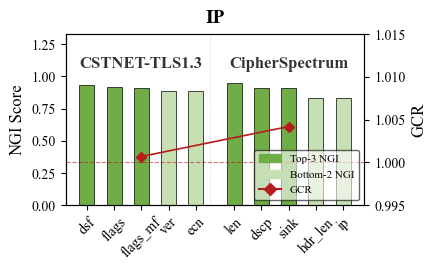

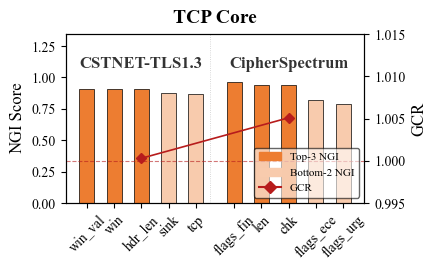

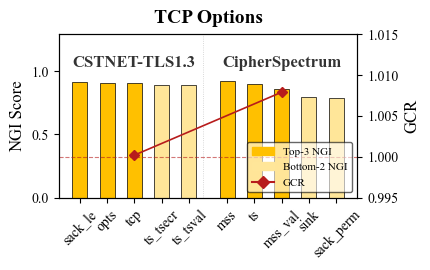

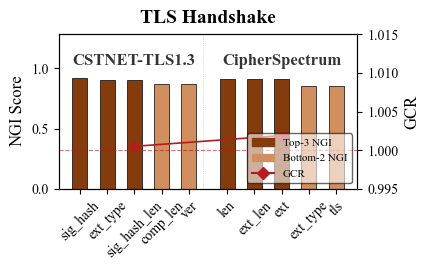

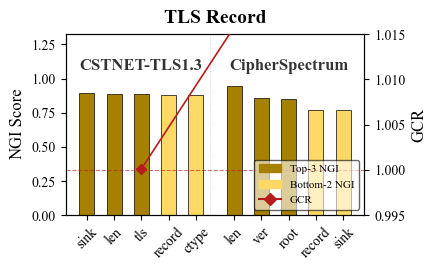

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np

# 1. 风格设置：IEEE TIFS 严谨学术风
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False

# 2. 数据准备：NGI 数据 (来自 Table III)
ngi_data = [
    # --- CSTNET-TLS1.3 ---
    ("IP", "CSTNET-TLS1.3", "dsf", 0.9293, "Top"),
    ("IP", "CSTNET-TLS1.3", "flags", 0.9143, "Top"),
    ("IP", "CSTNET-TLS1.3", "flags_mf", 0.9119, "Top"),
    ("IP", "CSTNET-TLS1.3", "ver", 0.8835, "Btm"),
    ("IP", "CSTNET-TLS1.3", "ecn", 0.8835, "Btm"),

    ("TCP Core", "CSTNET-TLS1.3", "win_val", 0.9108, "Top"),
    ("TCP Core", "CSTNET-TLS1.3", "win", 0.9094, "Top"),
    ("TCP Core", "CSTNET-TLS1.3", "hdr_len", 0.9063, "Top"),
    ("TCP Core", "CSTNET-TLS1.3", "sink", 0.8801, "Btm"),
    ("TCP Core", "CSTNET-TLS1.3", "tcp", 0.8705, "Btm"),

    ("TCP Options", "CSTNET-TLS1.3", "sack_le", 0.9106, "Top"),
    ("TCP Options", "CSTNET-TLS1.3", "opts", 0.9074, "Top"),
    ("TCP Options", "CSTNET-TLS1.3", "tcp", 0.9056, "Top"),
    ("TCP Options", "CSTNET-TLS1.3", "ts_tsecr", 0.8931, "Btm"),
    ("TCP Options", "CSTNET-TLS1.3", "ts_tsval", 0.8924, "Btm"),

    ("TLS Handshake", "CSTNET-TLS1.3", "sig_hash", 0.9167, "Top"),
    ("TLS Handshake", "CSTNET-TLS1.3", "ext_type", 0.9064, "Top"),
    ("TLS Handshake", "CSTNET-TLS1.3", "sig_hash_len", 0.9042, "Top"),
    ("TLS Handshake", "CSTNET-TLS1.3", "comp_len", 0.8730, "Btm"),
    ("TLS Handshake", "CSTNET-TLS1.3", "ver", 0.8727, "Btm"),

    ("TLS Record", "CSTNET-TLS1.3", "sink", 0.8913, "Top"),
    ("TLS Record", "CSTNET-TLS1.3", "len", 0.8904, "Top"),
    ("TLS Record", "CSTNET-TLS1.3", "tls", 0.8893, "Top"),
    ("TLS Record", "CSTNET-TLS1.3", "record", 0.8829, "Btm"),
    ("TLS Record", "CSTNET-TLS1.3", "ctype", 0.8829, "Btm"),

    # --- CipherSpectrum ---
    ("IP", "CipherSpectrum", "len", 0.9480, "Top"),
    ("IP", "CipherSpectrum", "dscp", 0.9087, "Top"),
    ("IP", "CipherSpectrum", "sink", 0.9064, "Top"),
    ("IP", "CipherSpectrum", "hdr_len", 0.8335, "Btm"),
    ("IP", "CipherSpectrum", "ip", 0.8329, "Btm"),

    ("TCP Core", "CipherSpectrum", "flags_fin", 0.9607, "Top"),
    ("TCP Core", "CipherSpectrum", "len", 0.9385, "Top"),
    ("TCP Core", "CipherSpectrum", "chk", 0.9381, "Top"),
    ("TCP Core", "CipherSpectrum", "flags_ece", 0.8194, "Btm"),
    ("TCP Core", "CipherSpectrum", "flags_urg", 0.7919, "Btm"),

    ("TCP Options", "CipherSpectrum", "mss", 0.9226, "Top"),
    ("TCP Options", "CipherSpectrum", "ts", 0.8982, "Top"),
    ("TCP Options", "CipherSpectrum", "mss_val", 0.8563, "Top"),
    ("TCP Options", "CipherSpectrum", "sink", 0.7918, "Btm"),
    ("TCP Options", "CipherSpectrum", "sack_perm", 0.7908, "Btm"),

    ("TLS Handshake", "CipherSpectrum", "len", 0.9153, "Top"),
    ("TLS Handshake", "CipherSpectrum", "ext_len", 0.9120, "Top"),
    ("TLS Handshake", "CipherSpectrum", "ext", 0.9074, "Top"),
    ("TLS Handshake", "CipherSpectrum", "ext_type", 0.8517, "Btm"),
    ("TLS Handshake", "CipherSpectrum", "tls", 0.8510, "Btm"),

    ("TLS Record", "CipherSpectrum", "len", 0.9464, "Top"),
    ("TLS Record", "CipherSpectrum", "ver", 0.8584, "Top"),
    ("TLS Record", "CipherSpectrum", "root", 0.8536, "Top"),
    ("TLS Record", "CipherSpectrum", "record", 0.7674, "Btm"),
    ("TLS Record", "CipherSpectrum", "sink", 0.7662, "Btm"),
]
# 3. 数据准备：GCR 数据 (Gate Concentration Ratio = logN / GCS)
gcr_data = {
    "IP": {
        "CSTNET-TLS1.3": 1.0007,
        "CipherSpectrum": 1.0042
    },
    "TCP Core": {
        "CSTNET-TLS1.3": 1.0003,
        "CipherSpectrum": 1.0051
    },
    "TCP Options": {
        "CSTNET-TLS1.3": 1.0002,
        "CipherSpectrum": 1.0079
    },
    "TLS Handshake": {
        "CSTNET-TLS1.3": 1.0005,
        "CipherSpectrum": 1.0019
    },
    "TLS Record": {
        "CSTNET-TLS1.3": 1.0001,
        "CipherSpectrum": 1.0250
    }
}

df = pd.DataFrame(ngi_data, columns=["Layer", "Dataset", "Field", "NGI", "Category"])
datasets_order = ["CSTNET-TLS1.3", "CipherSpectrum"]

color_map = {
    "ETH": {"Top": "#5B84C4", "Btm": "#B4C7E7"},
    "IP": {"Top": "#70AD47", "Btm": "#C6E0B4"},
    "TCP Core": {"Top": "#ED7D31", "Btm": "#F8CBAD"},
    "TCP Options": {"Top": "#FFC000", "Btm": "#FFE699"},
    "TLS Handshake": {"Top": "#843C0C", "Btm": "#D18E5E"},
    "TLS Record": {"Top": "#A68100", "Btm": "#FFD966"},
    "TLS X509": {"Top": "#7E6000", "Btm": "#C5A13E"},
}


def draw_tifs_integrated_refined_plot(layer_name):
    layer_df = df[df["Layer"] == layer_name]
    if layer_df.empty: return
    
    active_ds = [ds for ds in datasets_order if ds in layer_df["Dataset"].unique()]
    num_bars = len(layer_df)
    num_sets = len(active_ds)
    
    # 使用你设计的动态宽度公式
    fig_width = num_bars * 0.22 + (num_sets - 1) * 0.4 + 1.8
    fig, ax1 = plt.subplots(figsize=(fig_width, 2.8))
    
    colors = color_map.get(layer_name, {"Top": "gray", "Btm": "lightgray"})
    
    current_x = 0
    x_pos, x_labels = [], []
    gcr_x_coords, gcr_vals = [], []
    
    # --- 1. 绘制 NGI 条形图 (左轴) ---
    for idx, ds in enumerate(active_ds):
        ds_data = layer_df[layer_df["Dataset"] == ds].sort_values(by="Category", ascending=False)
        
        # 数据集标题对齐：y=max*1.12, size=12
        ds_center = current_x + (len(ds_data)-1)/2
        ax1.text(ds_center, layer_df["NGI"].max() * 1.12, ds, 
                ha='center', fontsize=12, fontweight='bold', color='#333333')
        
        # 记录 GCR 数据点位置
        gcr_x_coords.append(ds_center)
        gcr_vals.append(gcr_data.get(layer_name, {}).get(ds, 1.0))
        
        for row in ds_data.itertuples():
            bar_color = colors["Top"] if row.Category == "Top" else colors["Btm"]
            ax1.bar(current_x, row.NGI, color=bar_color, edgecolor='black', linewidth=0.5, width=0.55, zorder=2)
            x_pos.append(current_x)
            x_labels.append(row.Field)
            current_x += 1
            
        if idx < len(active_ds) - 1:
            ax1.axvline(x=current_x - 0.5, color='#CCCCCC', linestyle=':', linewidth=0.6, zorder=1)
            current_x += 0.4

    # --- 2. 绘制 GCR 趋势图 (右轴) ---
    ax2 = ax1.twinx()
    # 红色基准线
    ax2.axhline(y=1.0, color='#B71C1C', linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)
    # 红色连线与菱形
    ax2.plot(gcr_x_coords, gcr_vals, color='#B71C1C', marker='D', markersize=5, 
             linewidth=1.2, label='GCR', zorder=3)
    
    # 右轴颜色设置：统一为黑色 (需求1)
    ax2.set_ylim(0.995, 1.015) 
    ax2.set_ylabel("GCR", fontsize=12, color='black')
    ax2.tick_params(axis='y', labelsize=10, colors='black')

    # --- 3. 边框与标签设置 (需求2: 与原 NGI 代码一致) ---
    for spine in ax1.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('black')

    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(x_labels, rotation=45, ha='center', fontsize=10)
    ax1.set_ylabel("NGI Score", fontsize=12)
    ax1.set_ylim(0, layer_df["NGI"].max() * 1.4)
    ax1.set_title(f"{layer_name}", fontsize=14, fontweight='bold', pad=8)
    
    # # 4. 图例设置 (需求2: lower right, size 8)
    # top_patch = patches.Patch(color=colors["Top"], label='Top-3 NGI')
    # btm_patch = patches.Patch(color=colors["Btm"], label='Bottom-2 NGI')
    # line_patch = plt.Line2D([0], [0], color='#B71C1C', marker='D', linestyle='-', label='GCR')
    # ax1.legend(handles=[top_patch, btm_patch, line_patch], loc='lower right', 
    #            fontsize=8, frameon=True, edgecolor='black')

    # 4. 图例设置：改在 ax2 上生成，确保其处于最顶层
    top_patch = patches.Patch(color=colors["Top"], label='Top-3 NGI')
    btm_patch = patches.Patch(color=colors["Btm"], label='Bottom-2 NGI')
    line_patch = plt.Line2D([0], [0], color='#B71C1C', marker='D', linestyle='-', label='GCR')
    
    # 注意：这里改用 ax2.legend
    leg = ax2.legend(handles=[top_patch, btm_patch, line_patch], 
                     loc='lower right', 
                     fontsize=8, 
                     frameon=True, 
                     edgecolor='black')
    
    # 核心：显式提升 Legend 的层级
    leg.set_zorder(10) 
    
    # 如果 legend 背景需要不透明，可以加上这行（默认通常已经有背景了）
    leg.get_frame().set_alpha(0.6)

    plt.tight_layout()
    filename = f"TIFS_Integrated_{layer_name.replace(' ', '_')}"
    # plt.savefig(f"{filename}.pdf", bbox_inches='tight')
    plt.savefig(f"../NGI/{filename}.pdf", bbox_inches='tight')
    plt.show()
    plt.close()

# 生成
for l in df["Layer"].unique():
    draw_tifs_integrated_refined_plot(l)

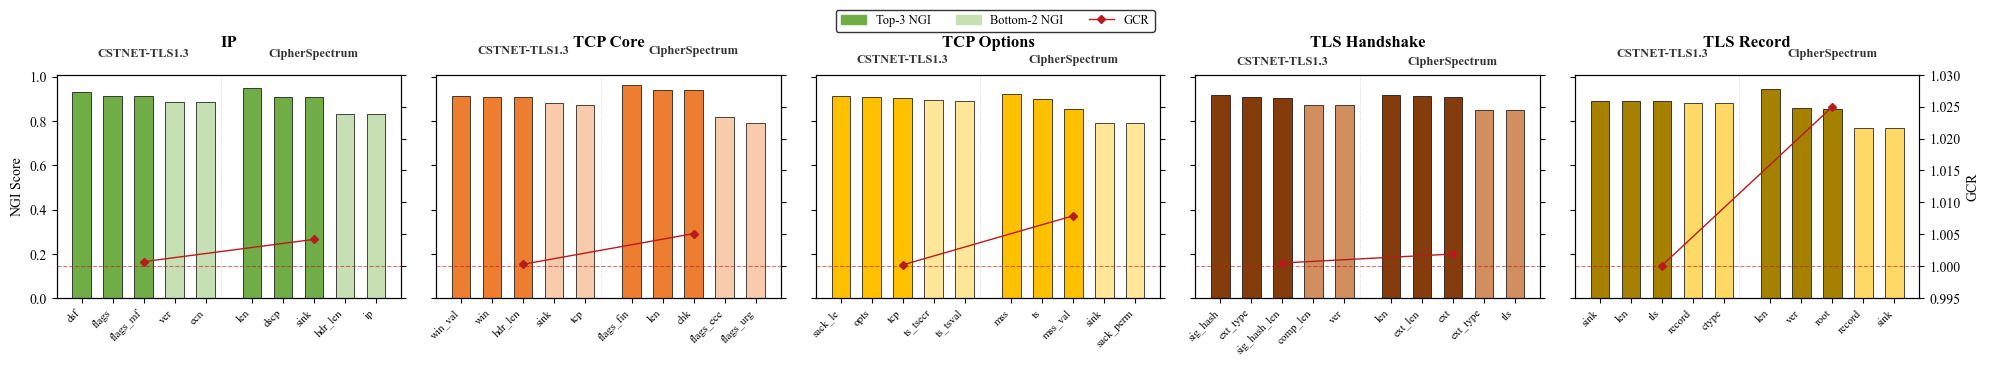

In [8]:
def draw_tifs_combined_plot(df, gcr_data):
    layers = df["Layer"].unique()
    num_layers = len(layers)
    
    # 计算总宽度：根据 Layer 数量动态调整
    # 假设每列宽度约为 3.5 inch
    fig, axes = plt.subplots(1, num_layers, figsize=(4 * num_layers, 3.5), sharey=True)
    plt.subplots_adjust(wspace=0.2) # 列间距

    # 存储图例句柄，最后统一生成一个图例
    legend_handles = []

    for i, layer_name in enumerate(layers):
        ax1 = axes[i]
        layer_df = df[df["Layer"] == layer_name]
        active_ds = [ds for ds in datasets_order if ds in layer_df["Dataset"].unique()]
        
        colors = color_map.get(layer_name, {"Top": "gray", "Btm": "lightgray"})
        
        current_x = 0
        x_pos, x_labels = [], []
        gcr_x_coords, gcr_vals = [], []

        # --- 1. 绘制 NGI 条形图 (左轴) ---
        for idx, ds in enumerate(active_ds):
            ds_data = layer_df[layer_df["Dataset"] == ds].sort_values(by="Category", ascending=False)
            
            # 数据集标题
            ds_center = current_x + (len(ds_data)-1)/2
            ax1.text(ds_center, layer_df["NGI"].max() * 1.15, ds, 
                    ha='center', fontsize=9, fontweight='bold', color='#333333')
            
            gcr_x_coords.append(ds_center)
            gcr_vals.append(gcr_data.get(layer_name, {}).get(ds, 1.0))
            
            for row in ds_data.itertuples():
                bar_color = colors["Top"] if row.Category == "Top" else colors["Btm"]
                bar = ax1.bar(current_x, row.NGI, color=bar_color, edgecolor='black', 
                               linewidth=0.5, width=0.6, zorder=2)
                x_pos.append(current_x)
                x_labels.append(row.Field)
                current_x += 1
            
            if idx < len(active_ds) - 1:
                ax1.axvline(x=current_x - 0.5, color='#CCCCCC', linestyle=':', linewidth=0.6, zorder=1)
                current_x += 0.5

        # --- 2. 绘制 GCR 趋势图 (右轴) ---
        ax2 = ax1.twinx()
        ax2.axhline(y=1.0, color='#B71C1C', linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)
        line, = ax2.plot(gcr_x_coords, gcr_vals, color='#B71C1C', marker='D', markersize=4, 
                        linewidth=1.0, label='GCR', zorder=3)
        
        # 只有最右边的子图显示右轴标签
        if i == num_layers - 1:
            ax2.set_ylabel("GCR", fontsize=10, color='black')
        else:
            ax2.set_yticklabels([]) # 隐藏中间子图的刻度数字

        ax2.set_ylim(0.995, 1.03) # 统一 GCR 范围

        # --- 3. 细节美化 ---
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
        ax1.set_title(layer_name, fontsize=12, fontweight='bold', pad=20)
        
        if i == 0:
            ax1.set_ylabel("NGI Score", fontsize=10)
        
        # 收集图例（仅记录一次）
        if i == 0:
            top_patch = patches.Patch(color=colors["Top"], label='Top-3 NGI')
            btm_patch = patches.Patch(color=colors["Btm"], label='Bottom-2 NGI')
            legend_handles = [top_patch, btm_patch, line]

    # --- 4. 统一图例 ---
    # 将图例放在整个画布的底部中央或右上角
    fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.05),
               ncol=3, fontsize=9, frameon=True, edgecolor='black')

    plt.tight_layout()
    plt.savefig("TIFS_Combined_Layers.pdf", bbox_inches='tight')
    plt.show()

# 调用
draw_tifs_combined_plot(df, gcr_data)

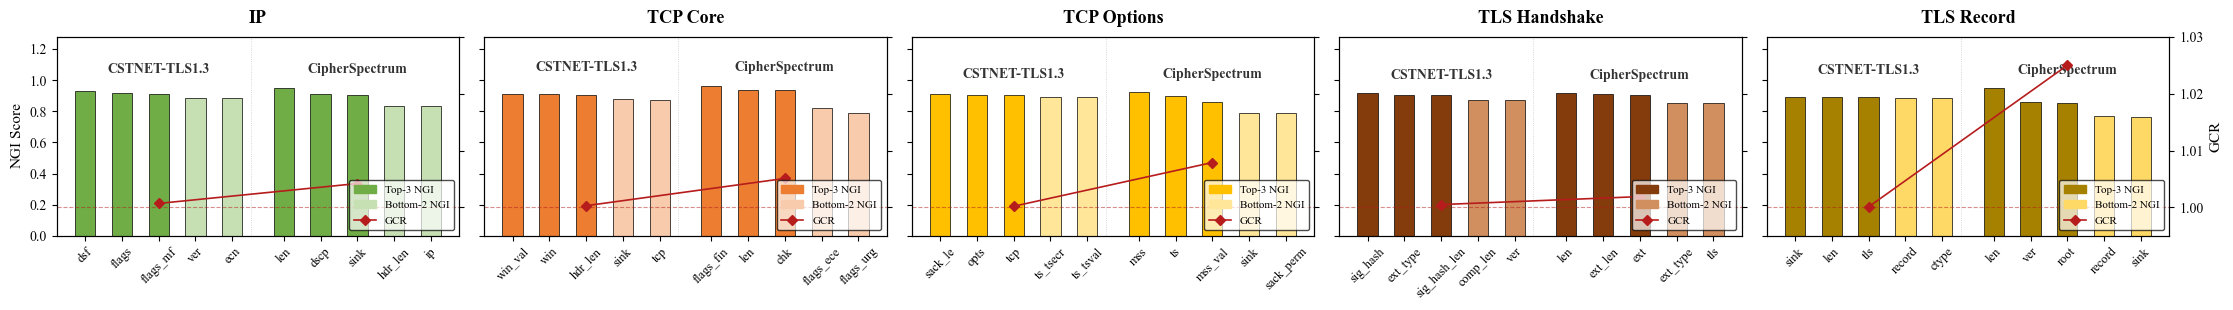

In [13]:
def draw_tifs_combined_with_internal_legends(df, gcr_data):
    layers = df["Layer"].unique()
    num_layers = len(layers)
    
    # 建立 1行 N列 的画布，sharey=True 保持 Y 轴刻度一致
    fig, axes = plt.subplots(1, num_layers, figsize=(4.5 * num_layers, 3.2), sharey=True)
    
    if num_layers == 1: axes = [axes]

    for i, layer_name in enumerate(layers):
        ax1 = axes[i]
        layer_df = df[df["Layer"] == layer_name]
        active_ds = [ds for ds in datasets_order if ds in layer_df["Dataset"].unique()]
        colors = color_map.get(layer_name, {"Top": "gray", "Btm": "lightgray"})
        
        current_x = 0
        x_pos, x_labels = [], []
        gcr_x_coords, gcr_vals = [], []

        # --- 1. 绘制 NGI 条形图 ---
        for idx, ds in enumerate(active_ds):
            ds_data = layer_df[layer_df["Dataset"] == ds].sort_values(by="Category", ascending=False)
            
            # 数据集名称标注
            ds_center = current_x + (len(ds_data)-1)/2
            ax1.text(ds_center, layer_df["NGI"].max() * 1.1, ds, 
                    ha='center', fontsize=10, fontweight='bold', color='#333333')
            
            gcr_x_coords.append(ds_center)
            gcr_vals.append(gcr_data.get(layer_name, {}).get(ds, 1.0))
            
            for row in ds_data.itertuples():
                bar_color = colors["Top"] if row.Category == "Top" else colors["Btm"]
                ax1.bar(current_x, row.NGI, color=bar_color, edgecolor='black', 
                        linewidth=0.5, width=0.55, zorder=2)
                x_pos.append(current_x)
                x_labels.append(row.Field)
                current_x += 1
            
            if idx < len(active_ds) - 1:
                ax1.axvline(x=current_x - 0.5, color='#CCCCCC', linestyle=':', linewidth=0.6)
                current_x += 0.4

        # --- 2. 绘制 GCR 趋势图 ---
        ax2 = ax1.twinx()
        ax2.axhline(y=1.0, color='#B71C1C', linestyle='--', linewidth=0.8, alpha=0.5)
        line, = ax2.plot(gcr_x_coords, gcr_vals, color='#B71C1C', marker='D', 
                        markersize=5, linewidth=1.2, label='GCR', zorder=4)
        
        # 只有最右侧显示右轴刻度
        if i == num_layers - 1:
            ax2.set_ylabel("GCR", fontsize=11)
        else:
            ax2.set_yticklabels([])

        # --- 3. 在每个子图内部添加 Legend ---
        top_patch = patches.Patch(color=colors["Top"], label='Top-3 NGI')
        btm_patch = patches.Patch(color=colors["Btm"], label='Bottom-2 NGI')
        
        # 统一放在右下角，保持整洁
        leg = ax2.legend(handles=[top_patch, btm_patch, line], 
                         loc='lower right', 
                         fontsize=8, 
                         frameon=True, 
                         edgecolor='black',
                         framealpha=0.7)
        leg.set_zorder(10)

        # --- 4. 坐标轴与标题 ---
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(x_labels, rotation=45, ha='center', fontsize=9)
        ax1.set_title(layer_name, fontsize=13, fontweight='bold', pad=10)
        
        if i == 0:
            ax1.set_ylabel("NGI Score", fontsize=11)
        
        # 维持原有的坐标限制，不额外增高
        ax1.set_ylim(0, layer_df["NGI"].max() * 1.35) 
        ax2.set_ylim(0.995, 1.03)

    plt.tight_layout()
    plt.savefig("../NGI/TIFS_Combined_PerLayerLegend.pdf", bbox_inches='tight')
    plt.show()

# 调用生成
draw_tifs_combined_with_internal_legends(df, gcr_data)

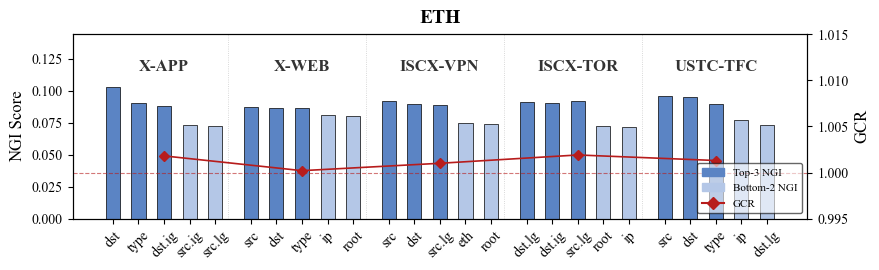

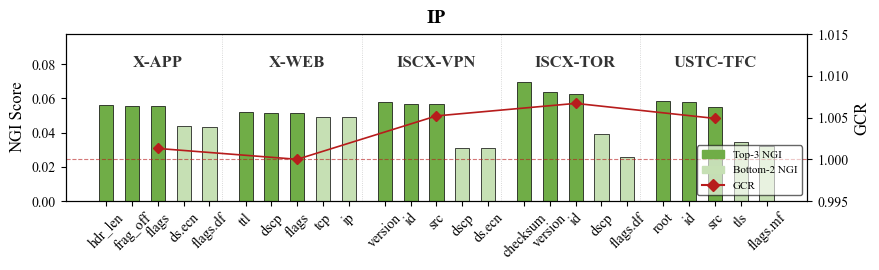

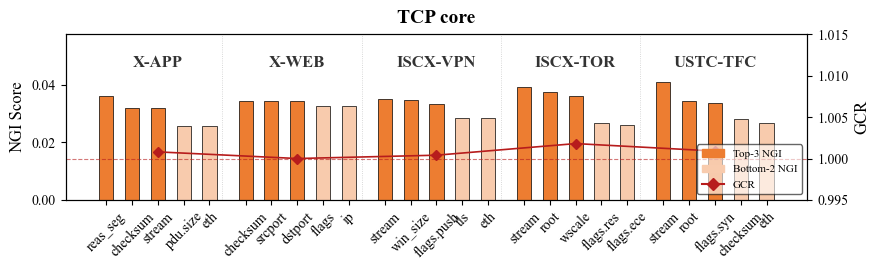

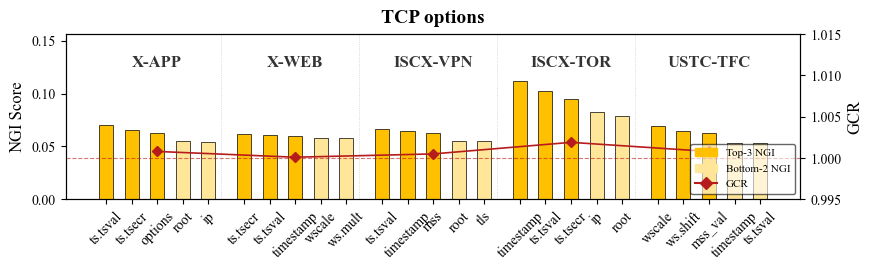

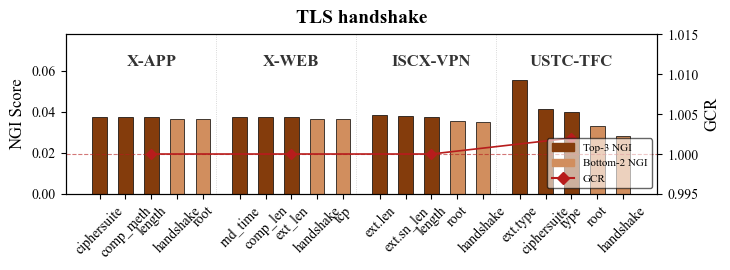

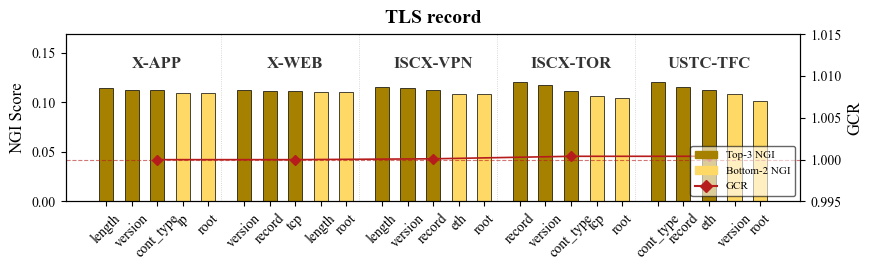

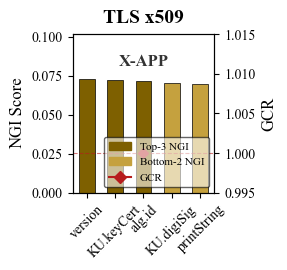

: 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np

# 1. 风格设置：IEEE TIFS 严谨学术风
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False

# 2. 数据准备：NGI 数据 (来自 Table III)
ngi_data = [
    # --- ETH ---
    ("ETH", "X-APP", "dst", 0.1030, "Top"), ("ETH", "X-APP", "type", 0.0907, "Top"), ("ETH", "X-APP", "dst.ig", 0.0882, "Top"),
    ("ETH", "X-APP", "src.ig", 0.0734, "Btm"), ("ETH", "X-APP", "src.lg", 0.0724, "Btm"),
    ("ETH", "X-WEB", "src", 0.0872, "Top"), ("ETH", "X-WEB", "dst", 0.0867, "Top"), ("ETH", "X-WEB", "type", 0.0861, "Top"),
    ("ETH", "X-WEB", "ip", 0.0807, "Btm"), ("ETH", "X-WEB", "root", 0.0805, "Btm"),
    ("ETH", "ISCX-VPN", "src", 0.0920, "Top"), ("ETH", "ISCX-VPN", "dst", 0.0896, "Top"), ("ETH", "ISCX-VPN", "src.lg", 0.0886, "Top"),
    ("ETH", "ISCX-VPN", "eth", 0.0744, "Btm"), ("ETH", "ISCX-VPN", "root", 0.0741, "Btm"),
    ("ETH", "ISCX-TOR", "dst.lg", 0.0909, "Top"), ("ETH", "ISCX-TOR", "dst.ig", 0.0905, "Top"), ("ETH", "ISCX-TOR", "src.lg", 0.0921, "Top"),
    ("ETH", "ISCX-TOR", "root", 0.0725, "Btm"), ("ETH", "ISCX-TOR", "ip", 0.0715, "Btm"),
    ("ETH", "USTC-TFC", "src", 0.0957, "Top"), ("ETH", "USTC-TFC", "dst", 0.0952, "Top"), ("ETH", "USTC-TFC", "type", 0.0899, "Top"),
    ("ETH", "USTC-TFC", "ip", 0.0769, "Btm"), ("ETH", "USTC-TFC", "dst.lg", 0.0734, "Btm"),

    # --- IP ---
    ("IP", "X-APP", "hdr_len", 0.0562, "Top"), ("IP", "X-APP", "frag_off", 0.0558, "Top"), ("IP", "X-APP", "flags", 0.0555, "Top"),
    ("IP", "X-APP", "ds.ecn", 0.0441, "Btm"), ("IP", "X-APP", "flags.df", 0.0433, "Btm"),
    ("IP", "X-WEB", "ttl", 0.0520, "Top"), ("IP", "X-WEB", "dscp", 0.0514, "Top"), ("IP", "X-WEB", "flags", 0.0512, "Top"),
    ("IP", "X-WEB", "tcp", 0.0492, "Btm"), ("IP", "X-WEB", "ip", 0.0490, "Btm"),
    ("IP", "ISCX-VPN", "version", 0.0580, "Top"), ("IP", "ISCX-VPN", "id", 0.0570, "Top"), ("IP", "ISCX-VPN", "src", 0.0568, "Top"),
    ("IP", "ISCX-VPN", "dscp", 0.0309, "Btm"), ("IP", "ISCX-VPN", "ds.ecn", 0.0308, "Btm"),
    ("IP", "ISCX-TOR", "checksum", 0.0697, "Top"), ("IP", "ISCX-TOR", "version", 0.0635, "Top"), ("IP", "ISCX-TOR", "id", 0.0628, "Top"),
    ("IP", "ISCX-TOR", "dscp", 0.0389, "Btm"), ("IP", "ISCX-TOR", "flags.df", 0.0258, "Btm"),
    ("IP", "USTC-TFC", "root", 0.0584, "Top"), ("IP", "USTC-TFC", "id", 0.0579, "Top"), ("IP", "USTC-TFC", "src", 0.0552, "Top"),
    ("IP", "USTC-TFC", "tls", 0.0348, "Btm"), ("IP", "USTC-TFC", "flags.mf", 0.0324, "Btm"),

    # --- TCP core ---
    ("TCP core", "X-APP", "reas_seg", 0.0362, "Top"), ("TCP core", "X-APP", "checksum", 0.0320, "Top"), ("TCP core", "X-APP", "stream", 0.0319, "Top"),
    ("TCP core", "X-APP", "pdu.size", 0.0257, "Btm"), ("TCP core", "X-APP", "eth", 0.0256, "Btm"),
    ("TCP core", "X-WEB", "checksum", 0.0345, "Top"), ("TCP core", "X-WEB", "srcport", 0.0344, "Top"), ("TCP core", "X-WEB", "dstport", 0.0344, "Top"),
    ("TCP core", "X-WEB", "flags", 0.0328, "Btm"), ("TCP core", "X-WEB", "ip", 0.0328, "Btm"),
    ("TCP core", "ISCX-VPN", "stream", 0.0350, "Top"), ("TCP core", "ISCX-VPN", "win_size", 0.0347, "Top"), ("TCP core", "ISCX-VPN", "flags.push", 0.0334, "Top"),
    ("TCP core", "ISCX-VPN", "tls", 0.0285, "Btm"), ("TCP core", "ISCX-VPN", "eth", 0.0285, "Btm"),
    ("TCP core", "ISCX-TOR", "stream", 0.0392, "Top"), ("TCP core", "ISCX-TOR", "root", 0.0375, "Top"), ("TCP core", "ISCX-TOR", "wscale", 0.0360, "Top"),
    ("TCP core", "ISCX-TOR", "flags.res", 0.0268, "Btm"), ("TCP core", "ISCX-TOR", "flags.ece", 0.0262, "Btm"),
    ("TCP core", "USTC-TFC", "stream", 0.0412, "Top"), ("TCP core", "USTC-TFC", "root", 0.0345, "Top"), ("TCP core", "USTC-TFC", "flags.syn", 0.0336, "Top"),
    ("TCP core", "USTC-TFC", "checksum", 0.0282, "Btm"), ("TCP core", "USTC-TFC", "eth", 0.0269, "Btm"),

    # --- TCP options ---
    ("TCP options", "X-APP", "ts.tsval", 0.0701, "Top"), ("TCP options", "X-APP", "ts.tsecr", 0.0656, "Top"), ("TCP options", "X-APP", "options", 0.0623, "Top"),
    ("TCP options", "X-APP", "root", 0.0547, "Btm"), ("TCP options", "X-APP", "ip", 0.0542, "Btm"),
    ("TCP options", "X-WEB", "ts.tsecr", 0.0616, "Top"), ("TCP options", "X-WEB", "ts.tsval", 0.0609, "Top"), ("TCP options", "X-WEB", "timestamp", 0.0596, "Top"),
    ("TCP options", "X-WEB", "wscale", 0.0577, "Btm"), ("TCP options", "X-WEB", "ws.mult", 0.0575, "Btm"),
    ("TCP options", "ISCX-VPN", "ts.tsval", 0.0667, "Top"), ("TCP options", "ISCX-VPN", "timestamp", 0.0647, "Top"), ("TCP options", "ISCX-VPN", "mss", 0.0626, "Top"),
    ("TCP options", "ISCX-VPN", "root", 0.0553, "Btm"), ("TCP options", "ISCX-VPN", "tls", 0.0552, "Btm"),
    ("TCP options", "ISCX-TOR", "timestamp", 0.1115, "Top"), ("TCP options", "ISCX-TOR", "ts.tsval", 0.1024, "Top"), ("TCP options", "ISCX-TOR", "ts.tsecr", 0.0944, "Top"),
    ("TCP options", "ISCX-TOR", "ip", 0.0827, "Btm"), ("TCP options", "ISCX-TOR", "root", 0.0792, "Btm"),
    ("TCP options", "USTC-TFC", "wscale", 0.0689, "Top"), ("TCP options", "USTC-TFC", "ws.shift", 0.0649, "Top"), ("TCP options", "USTC-TFC", "mss_val", 0.0624, "Top"),
    ("TCP options", "USTC-TFC", "timestamp", 0.0534, "Btm"), ("TCP options", "USTC-TFC", "ts.tsval", 0.0532, "Btm"),

    # --- TLS handshake ---
    ("TLS handshake", "X-APP", "ciphersuite", 0.0375, "Top"), ("TLS handshake", "X-APP", "comp_meth", 0.0375, "Top"), ("TLS handshake", "X-APP", "length", 0.0374, "Top"),
    ("TLS handshake", "X-APP", "handshake", 0.0363, "Btm"), ("TLS handshake", "X-APP", "root", 0.0363, "Btm"),
    ("TLS handshake", "X-WEB", "rnd_time", 0.0374, "Top"), ("TLS handshake", "X-WEB", "comp_len", 0.0373, "Top"), ("TLS handshake", "X-WEB", "ext_len", 0.0373, "Top"),
    ("TLS handshake", "X-WEB", "handshake", 0.0367, "Btm"), ("TLS handshake", "X-WEB", "tcp", 0.0366, "Btm"),
    ("TLS handshake", "ISCX-VPN", "ext.len", 0.0383, "Top"), ("TLS handshake", "ISCX-VPN", "ext.sn_len", 0.0378, "Top"), ("TLS handshake", "ISCX-VPN", "length", 0.0376, "Top"),
    ("TLS handshake", "ISCX-VPN", "root", 0.0357, "Btm"), ("TLS handshake", "ISCX-VPN", "handshake", 0.0350, "Btm"),
    ("TLS handshake", "USTC-TFC", "ext.type", 0.0556, "Top"), ("TLS handshake", "USTC-TFC", "ciphersuite", 0.0416, "Top"), ("TLS handshake", "USTC-TFC", "type", 0.0399, "Top"),
    ("TLS handshake", "USTC-TFC", "root", 0.0329, "Btm"), ("TLS handshake", "USTC-TFC", "handshake", 0.0280, "Btm"),

    # --- TLS record ---
    ("TLS record", "X-APP", "length", 0.1145, "Top"), ("TLS record", "X-APP", "version", 0.1126, "Top"), ("TLS record", "X-APP", "cont_type", 0.1119, "Top"),
    ("TLS record", "X-APP", "ip", 0.1093, "Btm"), ("TLS record", "X-APP", "root", 0.1090, "Btm"),
    ("TLS record", "X-WEB", "version", 0.1121, "Top"), ("TLS record", "X-WEB", "record", 0.1115, "Top"), ("TLS record", "X-WEB", "tcp", 0.1113, "Top"),
    ("TLS record", "X-WEB", "length", 0.1107, "Btm"), ("TLS record", "X-WEB", "root", 0.1107, "Btm"),
    ("TLS record", "ISCX-VPN", "length", 0.1148, "Top"), ("TLS record", "ISCX-VPN", "version", 0.1146, "Top"), ("TLS record", "ISCX-VPN", "record", 0.1125, "Top"),
    ("TLS record", "ISCX-VPN", "eth", 0.1081, "Btm"), ("TLS record", "ISCX-VPN", "root", 0.1081, "Btm"),
    ("TLS record", "ISCX-TOR", "record", 0.1200, "Top"), ("TLS record", "ISCX-TOR", "version", 0.1177, "Top"), ("TLS record", "ISCX-TOR", "cont_type", 0.1114, "Top"),
    ("TLS record", "ISCX-TOR", "tcp", 0.1067, "Btm"), ("TLS record", "ISCX-TOR", "root", 0.1045, "Btm"),
    ("TLS record", "USTC-TFC", "cont_type", 0.1204, "Top"), ("TLS record", "USTC-TFC", "record", 0.1149, "Top"), ("TLS record", "USTC-TFC", "eth", 0.1123, "Top"),
    ("TLS record", "USTC-TFC", "version", 0.1080, "Btm"), ("TLS record", "USTC-TFC", "root", 0.1013, "Btm"),

    # --- TLS x509 ---
    ("TLS x509", "X-APP", "version", 0.0726, "Top"), ("TLS x509", "X-APP", "KU.keyCert", 0.0725, "Top"), ("TLS x509", "X-APP", "alg.id", 0.0719, "Top"),
    ("TLS x509", "X-APP", "KU.digiSig", 0.0706, "Btm"), ("TLS x509", "X-APP", "printString", 0.0696, "Btm")
]
# 3. 数据准备：GCR 数据 (Gate Concentration Ratio = logN / GCS)
gcr_data = {
    "ETH": {"X-APP": 1.0018, "X-WEB": 1.0002, "ISCX-VPN": 1.0010, "ISCX-TOR": 1.0019, "USTC-TFC": 1.0013},
    "IP": {"X-APP": 1.0013, "X-WEB": 1.0000, "ISCX-VPN": 1.0052, "ISCX-TOR": 1.0067, "USTC-TFC": 1.0049},
    "TCP core": {"X-APP": 1.0008, "X-WEB": 1.0000, "ISCX-VPN": 1.0004, "ISCX-TOR": 1.0018, "USTC-TFC": 1.0009},
    "TCP options": {"X-APP": 1.0008, "X-WEB": 1.0001, "ISCX-VPN": 1.0005, "ISCX-TOR": 1.0019, "USTC-TFC": 1.0008},
    "TLS handshake": {"X-APP": 1.0000, "X-WEB": 1.0000, "ISCX-VPN": 1.0000, "USTC-TFC": 1.0020},
    "TLS record": {"X-APP": 1.0000, "X-WEB": 1.0000, "ISCX-VPN": 1.0001, "ISCX-TOR": 1.0004, "USTC-TFC": 1.0004},
    "TLS x509": {"X-APP": 1.0000}
}

df = pd.DataFrame(ngi_data, columns=["Layer", "Dataset", "Field", "NGI", "Category"])
datasets_order = ["X-APP", "X-WEB", "ISCX-VPN", "ISCX-TOR", "USTC-TFC"]

color_map = {
    "ETH": {"Top": "#5B84C4", "Btm": "#B4C7E7"},
    "IP": {"Top": "#70AD47", "Btm": "#C6E0B4"},
    "TCP core": {"Top": "#ED7D31", "Btm": "#F8CBAD"},
    "TCP options": {"Top": "#FFC000", "Btm": "#FFE699"},
    "TLS handshake": {"Top": "#843C0C", "Btm": "#D18E5E"},
    "TLS record": {"Top": "#A68100", "Btm": "#FFD966"},
    "TLS x509": {"Top": "#7E6000", "Btm": "#C5A13E"},
}


def draw_tifs_integrated_refined_plot(layer_name):
    layer_df = df[df["Layer"] == layer_name]
    if layer_df.empty: return
    
    active_ds = [ds for ds in datasets_order if ds in layer_df["Dataset"].unique()]
    num_bars = len(layer_df)
    num_sets = len(active_ds)
    
    # 使用你设计的动态宽度公式
    fig_width = num_bars * 0.22 + (num_sets - 1) * 0.4 + 1.8
    fig, ax1 = plt.subplots(figsize=(fig_width, 2.8))
    
    colors = color_map.get(layer_name, {"Top": "gray", "Btm": "lightgray"})
    
    current_x = 0
    x_pos, x_labels = [], []
    gcr_x_coords, gcr_vals = [], []
    
    # --- 1. 绘制 NGI 条形图 (左轴) ---
    for idx, ds in enumerate(active_ds):
        ds_data = layer_df[layer_df["Dataset"] == ds].sort_values(by="Category", ascending=False)
        
        # 数据集标题对齐：y=max*1.12, size=12
        ds_center = current_x + (len(ds_data)-1)/2
        ax1.text(ds_center, layer_df["NGI"].max() * 1.12, ds, 
                ha='center', fontsize=12, fontweight='bold', color='#333333')
        
        # 记录 GCR 数据点位置
        gcr_x_coords.append(ds_center)
        gcr_vals.append(gcr_data.get(layer_name, {}).get(ds, 1.0))
        
        for row in ds_data.itertuples():
            bar_color = colors["Top"] if row.Category == "Top" else colors["Btm"]
            ax1.bar(current_x, row.NGI, color=bar_color, edgecolor='black', linewidth=0.5, width=0.55, zorder=2)
            x_pos.append(current_x)
            x_labels.append(row.Field)
            current_x += 1
            
        if idx < len(active_ds) - 1:
            ax1.axvline(x=current_x - 0.5, color='#CCCCCC', linestyle=':', linewidth=0.6, zorder=1)
            current_x += 0.4

    # --- 2. 绘制 GCR 趋势图 (右轴) ---
    ax2 = ax1.twinx()
    # 红色基准线
    ax2.axhline(y=1.0, color='#B71C1C', linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)
    # 红色连线与菱形
    ax2.plot(gcr_x_coords, gcr_vals, color='#B71C1C', marker='D', markersize=5, 
             linewidth=1.2, label='GCR', zorder=3)
    
    # 右轴颜色设置：统一为黑色 (需求1)
    ax2.set_ylim(0.995, 1.015) 
    ax2.set_ylabel("GCR", fontsize=12, color='black')
    ax2.tick_params(axis='y', labelsize=10, colors='black')

    # --- 3. 边框与标签设置 (需求2: 与原 NGI 代码一致) ---
    for spine in ax1.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('black')

    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(x_labels, rotation=45, ha='center', fontsize=10)
    ax1.set_ylabel("NGI Score", fontsize=12)
    ax1.set_ylim(0, layer_df["NGI"].max() * 1.4)
    ax1.set_title(f"{layer_name}", fontsize=14, fontweight='bold', pad=8)
    
    # # 4. 图例设置 (需求2: lower right, size 8)
    # top_patch = patches.Patch(color=colors["Top"], label='Top-3 NGI')
    # btm_patch = patches.Patch(color=colors["Btm"], label='Bottom-2 NGI')
    # line_patch = plt.Line2D([0], [0], color='#B71C1C', marker='D', linestyle='-', label='GCR')
    # ax1.legend(handles=[top_patch, btm_patch, line_patch], loc='lower right', 
    #            fontsize=8, frameon=True, edgecolor='black')

    # 4. 图例设置：改在 ax2 上生成，确保其处于最顶层
    top_patch = patches.Patch(color=colors["Top"], label='Top-3 NGI')
    btm_patch = patches.Patch(color=colors["Btm"], label='Bottom-2 NGI')
    line_patch = plt.Line2D([0], [0], color='#B71C1C', marker='D', linestyle='-', label='GCR')
    
    # 注意：这里改用 ax2.legend
    leg = ax2.legend(handles=[top_patch, btm_patch, line_patch], 
                     loc='lower right', 
                     fontsize=8, 
                     frameon=True, 
                     edgecolor='black')
    
    # 核心：显式提升 Legend 的层级
    leg.set_zorder(10) 
    
    # 如果 legend 背景需要不透明，可以加上这行（默认通常已经有背景了）
    leg.get_frame().set_alpha(0.6)

    plt.tight_layout()
    filename = f"TIFS_Integrated_{layer_name.replace(' ', '_')}"
    # plt.savefig(f"{filename}.pdf", bbox_inches='tight')
    plt.savefig(f"../NGI/{filename}.pdf", bbox_inches='tight')
    plt.show()
    plt.close()

# 生成
for l in df["Layer"].unique():
    draw_tifs_integrated_refined_plot(l)